# NB02 - La regresion logistica como Modelo Lineal Generalizado

**Objetivos de aprendizaje**

- Ubicar la regresion logistica dentro del marco GLM.
- Ajustar un modelo binomial con enlace logit usando statsmodels.
- Interpretar coeficientes, errores estandar, valores z, p-valores e intervalos.
- Contrastar la vision inferencial de statsmodels con la vision predictiva de scikit-learn.
- Entender deviance, log-verosimilitud e IRLS a nivel conceptual.

En todo el notebook mantenemos la convenci?n global del repositorio: `virginica = 1` es la clase positiva y `versicolor = 0` es la clase negativa.

**Referencias de este notebook**

- Nelder & Wedderburn (1972): introducen los Modelos Lineales Generalizados.
- McCullagh & Nelder (1989): desarrollan deviance, residuos e IRLS.
- Agresti (2013): aplica el marco GLM a datos categoricos y regresion logistica.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression


## 1. El marco GLM

Nelder & Wedderburn (1972) unificaron modelos como regresion lineal, Poisson y logistica mediante tres piezas: una distribucion para la respuesta, un predictor lineal y una funcion de enlace. En regresion logistica, la respuesta es binomial y el enlace canonico es el logit.


In [2]:
data = load_processed_splits(DATA_DIR)
X_train_scaled = data["X_train_scaled"]
X_test_scaled = data["X_test_scaled"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]

glm_componentes = pd.DataFrame(
    {
        "pieza": ["Componente aleatorio", "Predictor lineal", "Funcion de enlace"],
        "en_logistica": ["Binomial/Bernoulli", "beta0 + beta^T x", "logit(p) = log(p/(1-p))"],
        "idea": [
            "La respuesta es 0/1",
            "Las variables entran linealmente",
            "La probabilidad se expresa como log-odds",
        ],
    }
)
display(glm_componentes)


,pieza,en_logistica,idea
0,Componente aleatorio,Binomial/Bernoulli,La respuesta es 0/1
1,Predictor lineal,beta0 + beta^T x,Las variables entran linealmente
2,Funcion de enlace,logit(p) = log(p/(1-p)),La probabilidad se expresa como log-odds


## 2. Ajuste con statsmodels

statsmodels prioriza la inferencia: estima coeficientes, errores estandar, estadisticos z, p-valores e intervalos de confianza. Esa salida permite discutir incertidumbre, no solo prediccion.


In [3]:
# Agregamos constante porque statsmodels no incluye intercepto
# automaticamente en GLM.
X_train_sm = sm.add_constant(X_train_scaled, has_constant="add")
glm_binomial = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
glm_results = glm_binomial.fit()

print(glm_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:              virginica   No. Observations:                   70
Model:                            GLM   Df Residuals:                       65
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4.2283
Date:                Tue, 16 Jun 2026   Deviance:                       8.4566
Time:                        22:47:25   Pearson chi2:                     7.81
No. Iterations:                    10   Pseudo R-squ. (CS):             0.7179
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4640      0.97

In [4]:
# Extraemos la tabla principal para interpretarla de forma compacta.
conf_int = glm_results.conf_int()
summary_table = pd.DataFrame(
    {
        "coef": glm_results.params,
        "std_err": glm_results.bse,
        "z": glm_results.tvalues,
        "p_value": glm_results.pvalues,
        "ci_low": conf_int[0],
        "ci_high": conf_int[1],
        "odds_ratio": np.exp(glm_results.params),
    }
)
display(summary_table.round(4))


,coef,std_err,z,p_value,ci_low,ci_high,odds_ratio
const,0.4640,0.9764,0.4753,0.6346,-1.4496,2.3777,1.5905
sepal length (cm),-1.0325,2.1558,-0.4789,0.6320,-5.2577,3.1928,0.3561
sepal width (cm),-0.7717,2.1450,-0.3598,0.7190,-4.9758,3.4323,0.4622
petal length (cm),5.1925,4.0153,1.2932,0.1959,-2.6773,13.0624,179.9263
petal width (cm),6.3971,3.2852,1.9473,0.0515,-0.0417,12.8360,600.1282


**Interpretacion.** Cada coeficiente vive en escala log-odds: valores positivos aumentan la probabilidad de `virginica`. El error estandar cuantifica incertidumbre; el valor z compara el coeficiente con su error; el p-valor aproxima evidencia contra coeficiente cero. Agresti (2013) usa esta lectura para conectar regresion logistica con analisis de datos categoricos.


## 3. statsmodels vs scikit-learn

La eleccion de herramienta depende de la pregunta: inferencia estadistica o rendimiento predictivo regularizado.


In [5]:
comparacion_herramientas = pd.DataFrame(
    {
        "statsmodels": [
            "Inferencia y tablas estadisticas",
            "p-valores e intervalos de confianza",
            "Deviance, log-verosimilitud y diagnostico GLM",
        ],
        "scikit-learn": [
            "Pipelines predictivos y validacion cruzada",
            "Regularizacion L1/L2/Elastic Net",
            "Integracion con metricas y busquedas de hiperparametros",
        ],
    },
    index=["Fortaleza 1", "Fortaleza 2", "Fortaleza 3"],
)
display(comparacion_herramientas)


,statsmodels,scikit-learn
Fortaleza 1,Inferencia y tablas estadisticas,Pipelines predictivos y validacion cruzada
Fortaleza 2,p-valores e intervalos de confianza,Regularizacion L1/L2/Elastic Net
Fortaleza 3,"Deviance, log-verosimilitud y diagnostico GLM",Integracion con metricas y busquedas de hiperp...


## 4. IRLS, deviance y log-verosimilitud

McCullagh & Nelder (1989) desarrollan la mecanica de los GLM. El ajuste se puede ver como minimos cuadrados reponderados iterativamente (IRLS): en cada iteracion el modelo construye una aproximacion cuadratica ponderada y actualiza los coeficientes.


In [6]:
# La deviance resume falta de ajuste relativa: menor es mejor al comparar
# modelos anidados o especificaciones sobre los mismos datos.
metricas_glm = pd.DataFrame(
    {
        "metrica": ["Log-verosimilitud", "Deviance", "Pearson chi2", "Iteraciones IRLS"],
        "valor": [
            glm_results.llf,
            glm_results.deviance,
            glm_results.pearson_chi2,
            glm_results.fit_history.get("iteration", np.nan),
        ],
    }
)
display(metricas_glm.round(4))


,metrica,valor
0,Log-verosimilitud,-4.2283
1,Deviance,8.4566
2,Pearson chi2,7.8115
3,Iteraciones IRLS,10.0000


**Interpretacion.** La log-verosimilitud mide que tan plausibles son los datos bajo el modelo ajustado. La deviance traduce esa informacion a una escala de discrepancia; por eso es central en la teoria GLM de McCullagh & Nelder (1989).


## 5. Coeficientes con intervalos de confianza

Visualizar incertidumbre evita leer los coeficientes como numeros exactos. El intervalo de confianza muestra el rango compatible con la estimacion asintotica.


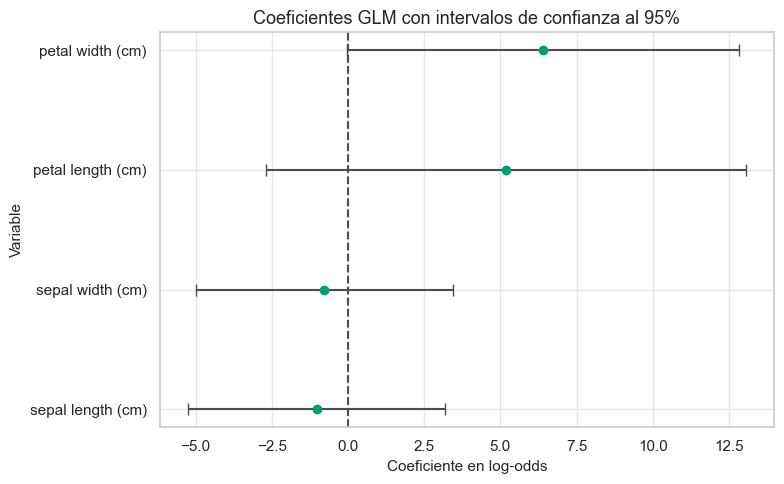

In [7]:
# Excluimos el intercepto para enfocar la figura en las variables.
coef_plot = summary_table.drop(index="const").copy()
y_pos = np.arange(len(coef_plot))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    coef_plot["coef"],
    y_pos,
    xerr=[
        coef_plot["coef"] - coef_plot["ci_low"],
        coef_plot["ci_high"] - coef_plot["coef"],
    ],
    fmt="o",
    color=COLOR_PALETTE["decision"],
    ecolor=COLOR_PALETTE["neutral"],
    capsize=4,
)
ax.axvline(0, color=COLOR_PALETTE["neutral"], linestyle="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_plot.index)
ax.set_title("Coeficientes GLM con intervalos de confianza al 95%")
ax.set_xlabel("Coeficiente en log-odds")
ax.set_ylabel("Variable")
fig.tight_layout()
plt.show()


**Interpretacion.** Las variables de petalo dominan la senal, pero los intervalos recuerdan que las cuatro variables estan correlacionadas y el tamano de muestra es pequeno. La inferencia ayuda a no sobreinterpretar pequenas diferencias numericas.


## Resumen y conexion con la literatura

Nelder & Wedderburn (1972) aportan el marco GLM que une familia binomial, predictor lineal y enlace logit. McCullagh & Nelder (1989) explican por que deviance e IRLS son piezas naturales de ese marco. Agresti (2013) conecta estas herramientas con la interpretacion practica de coeficientes, odds ratios e incertidumbre en respuestas categoricas.
